In [1]:
import ast
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from PySparseCoalescedTsetlinMachineCUDA.tm import MultiOutputTsetlinMachine

# Read the data

In [2]:
filepath = '../../data/stortinget_dataset_clean.csv'
df = pd.read_csv(filepath)
df['emneord'] = df['emneord'].apply(ast.literal_eval)
df.head()

,sakid,tittel,emneord,url,sammendrag,vedtak,text,html,tilrading
0,27712,"Forslag fra Gunnar Skaug, Carl I. Hagen, Einar...","[Grunnloven, Massemedier, Menneskerettigheter,...",https://www.stortinget.no/no/Saker-og-publikas...,Til Stortinget 1.\tInnledning Dokument nr. 12:...,I Dokument nr. 12:16 (1999-2000) - forslag fra...,Innst. S. nr. 270 (2003-2004) - stortinget.no ...,"\n<!DOCTYPE html>\n\n<html class=""no-js"" lang=...",NaN
1,27709,"Forslag fra Thomas Chr. Wyller, vedtatt til fr...","[Grunnloven, Statsforfatning, Eu/eøs, Internas...",https://www.stortinget.no/no/Saker-og-publikas...,Til Stortinget Sammendrag I Dokument nr. 12 (1...,"I Dokument nr. 12:13 (1999-2000), forslag fra\...",Innst. S. nr. 190 (2003-2004) - stortinget.no ...,"\n<!DOCTYPE html>\n\n<html class=""no-js"" lang=...",NaN
2,27715,Forslag fra Carl I. Hagen om ny § 110 d i Grun...,"[Grunnloven, Olje og gass, Trygder]",https://www.stortinget.no/no/Saker-og-publikas...,Til Stortinget Sammendrag Ovennevnte grunnlovs...,NaN,Innst. S. nr. 206 (2003-2004) - stortinget.no ...,"\n<!DOCTYPE html>\n\n<html class=""no-js"" lang=...",NaN
3,27716,Forslag fra Carl I. Hagen om ny § 110 e i Grun...,"[Grunnloven, Trygder]",https://www.stortinget.no/no/Saker-og-publikas...,Til Stortinget Sammendrag Ovennevnte grunnlovs...,NaN,Innst. S. nr. 207 (2003-2004) - stortinget.no ...,"\n<!DOCTYPE html>\n\n<html class=""no-js"" lang=...",NaN
4,27704,Forslag fra Øystein Djupedal og Rolf Reikvam o...,"[Kongen, Grunnloven, Statsforfatning]",https://www.stortinget.no/no/Saker-og-publikas...,Til Stortinget Sammendrag Ovennevnte grunnlovs...,NaN,Innst. S. nr. 209 (2003-2004) - stortinget.no ...,"\n<!DOCTYPE html>\n\n<html class=""no-js"" lang=...",NaN


In [3]:
print(df.shape)

(9468, 9)


# Preprocessing

In [4]:
all_emneord = np.sort(np.unique(df['emneord'].sum()))
emnedict = {str(k): v for v, k in zip(range(len(all_emneord)), all_emneord)}

print(f"Number of unique labels: {len(emnedict)}")

# Use only the 10 most common labels
tags, counts = np.unique(df['emneord'].sum(), return_counts=True)
common_tags_ind = np.argsort(-counts)[:10]

print("Most common labels\n", "-"*20)
emnedict_reduced = {}
for i, tag in enumerate(common_tags_ind):
    print(f"{tags[tag]} -- {counts[tag]}")
    emnedict_reduced[str(tags[tag])] = i

print(f"\nReduced emnedict: {emnedict_reduced}")

Number of unique labels: 163
Most common labels
 --------------------
Eu/eøs -- 1090
Trygder -- 810
Helsevesen -- 791
Innvandrere -- 650
Forurensning -- 629
Internasjonalt samarbeid -- 535
Politi og påtalemyndighet -- 513
Departementer -- 502
Forskning -- 496
Kommunikasjonsteknologi -- 491

Reduced emnedict: {'Eu/eøs': 0, 'Trygder': 1, 'Helsevesen': 2, 'Innvandrere': 3, 'Forurensning': 4, 'Internasjonalt samarbeid': 5, 'Politi og påtalemyndighet': 6, 'Departementer': 7, 'Forskning': 8, 'Kommunikasjonsteknologi': 9}


In [90]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split as tts


train, test = tts(df, test_size=0.2, random_state=1)
test_samples = test.index
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

corpus = list(train.loc[:, 'sammendrag'].values)
vect = CountVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    binary=True,
)

tic = time()
vect.fit(corpus)
toc = time()
print(f"Vectorizer trained in {toc - tic:.3f} seconds")

tic = time()
X_train = vect.transform(corpus).toarray()
toc = time()
print(f"Corpus transformed in {toc-tic:.3f} seconds")

tic = time()
X_test = vect.transform(list(test.loc[:, 'sammendrag'].values)).toarray()
toc = time()
print(f"Test data transformed in {toc-tic:.3f} seconds")

Vectorizer trained in 64.117 seconds
Corpus transformed in 35.332 seconds
Test data transformed in 10.120 seconds


In [93]:
# Get the encoded labels

emneset = set(emnedict_reduced.keys())
def get_target_vect(df, emneset):
    Y = np.zeros([df.shape[0], len(emneset)], dtype=int)
    for i in range(df.shape[0]):
        labels = set(df.loc[i, 'emneord']).intersection(emneset)
        for l in labels:
            Y[i, emnedict_reduced[l]] = 1
    return Y


Y_train = get_target_vect(train.iloc[:], emneset)
Y_test = get_target_vect(test.iloc[:], emneset)

# Remove samples without any labels
X_train = X_train[np.sum(Y_train, axis=1) > 0]
Y_train = Y_train[np.sum(Y_train, axis=1) > 0]
X_test = X_test[np.sum(Y_test, axis=1) > 0]
Y_test = Y_test[np.sum(Y_test, axis=1) > 0]

print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of test samples:     {X_test.shape[0]}")

In [261]:
tm = MultiOutputTsetlinMachine(
    number_of_clauses=20000,
    T=41000,
    s=1.0,
    q=2,
    max_included_literals=16,
)

for i in range(3):
    tm.fit(X_train, Y_train, epochs=1)
    Y_pred, cs = tm.predict(X_test)
    print(f"-- {i} --", end='\n')
    print(classification_report(Y_test, Y_pred, target_names=emnedict_reduced.keys(), zero_division=np.nan))

# Get the clauses
L = tm.get_literals()

-- 0 --
                           precision    recall  f1-score   support

                   Eu/eøs       0.80      0.89      0.84       213
                  Trygder       0.74      0.96      0.83       160
               Helsevesen       0.81      0.90      0.85       155
              Innvandrere       0.73      0.86      0.79       115
             Forurensning       0.81      0.89      0.85       131
 Internasjonalt samarbeid       0.52      0.88      0.66       107
Politi og påtalemyndighet       0.82      0.92      0.87        91
            Departementer       0.47      0.89      0.61        96
                Forskning       0.50      0.65      0.57       108
  Kommunikasjonsteknologi       0.67      0.73      0.70        96

                micro avg       0.69      0.86      0.77      1272
                macro avg       0.69      0.86      0.76      1272
             weighted avg       0.71      0.86      0.77      1272
              samples avg       0.78      0.89      

-- 1 --
                           precision    recall  f1-score   support

                   Eu/eøs       0.81      0.89      0.85       213
                  Trygder       0.73      0.96      0.83       160
               Helsevesen       0.82      0.90      0.86       155
              Innvandrere       0.72      0.86      0.78       115
             Forurensning       0.82      0.89      0.85       131
 Internasjonalt samarbeid       0.51      0.89      0.65       107
Politi og påtalemyndighet       0.82      0.92      0.87        91
            Departementer       0.47      0.90      0.62        96
                Forskning       0.52      0.65      0.58       108
  Kommunikasjonsteknologi       0.67      0.73      0.70        96

                micro avg       0.69      0.87      0.77      1272
                macro avg       0.69      0.86      0.76      1272
             weighted avg       0.71      0.87      0.77      1272
              samples avg       0.78      0.89      

-- 2 --
                           precision    recall  f1-score   support

                   Eu/eøs       0.81      0.89      0.85       213
                  Trygder       0.76      0.96      0.85       160
               Helsevesen       0.84      0.88      0.86       155
              Innvandrere       0.72      0.86      0.79       115
             Forurensning       0.81      0.90      0.86       131
 Internasjonalt samarbeid       0.51      0.88      0.65       107
Politi og påtalemyndighet       0.83      0.92      0.88        91
            Departementer       0.45      0.89      0.60        96
                Forskning       0.51      0.66      0.58       108
  Kommunikasjonsteknologi       0.69      0.73      0.71        96

                micro avg       0.69      0.86      0.77      1272
                macro avg       0.69      0.86      0.76      1272
             weighted avg       0.71      0.86      0.78      1272
              samples avg       0.78      0.90      

True features: 
 ['Politi og påtalemyndighet']


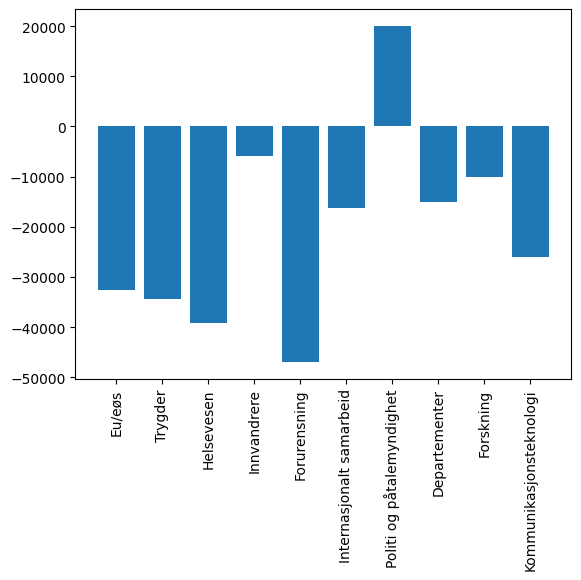

In [273]:
sample_id = 12

Y_pred, cs = tm.predict(X_train)
reverse_dict = {v:k for k, v in emnedict_reduced.items()}
print("True features: \n", [[reverse_dict[int(label)] for label in x] for x in np.nonzero(Y_train[sample_id])][0])

fig, ax = plt.subplots()
ax.bar(emnedict_reduced.keys(), cs[sample_id])
ax.tick_params(axis='x', labelrotation=90)

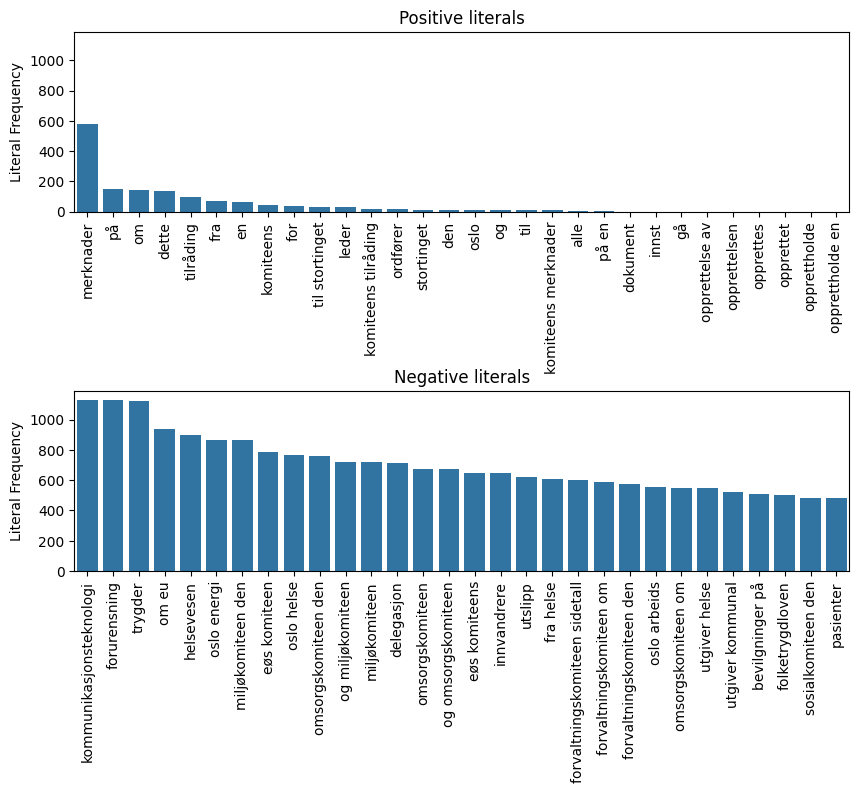

In [274]:
#sample_id = 12

# Get active clauses
T_train = tm.transform(X_train[sample_id].reshape(1, -1))

# Get the clauses. 
# Shape: [number_of_clauses X number of features
L_active = L[T_train.toarray()[0] == 1, :]
Lpos = L_active[:, :L.shape[1]//2].astype(int)
Lneg = L_active[:, L.shape[1]//2:].astype(int)

# Show most common word in active clauses
n_words = 30

df_pos = pd.DataFrame(data={'words':vect.get_feature_names_out(), 'literal freq':Lpos.sum(axis=0)})
df_pos = df_pos.sort_values('literal freq', ascending=False).reset_index(drop=True)[:n_words]

# Show the most common words
df_neg = pd.DataFrame(data={'words':vect.get_feature_names_out(), 'literal freq':Lneg.sum(axis=0)})
df_neg = df_neg.sort_values('literal freq', ascending=False).reset_index(drop=True)[:n_words]

fig, axs = plt.subplots(2, 1, figsize=[10, 7], sharey=True, gridspec_kw={'hspace':1})

sns.barplot(x='words', y='literal freq', data=df_pos, ax=axs[0])
axs[0].set(ylabel='Literal Frequency', xlabel='')
axs[0].tick_params(axis='x', labelrotation=90)
axs[0].set_title('Positive literals')


sns.barplot(x='words', y='literal freq', data=df_neg, ax=axs[1])
axs[1].set(ylabel='Literal Frequency', xlabel='')
axs[1].tick_params(axis='x', labelrotation=90)
axs[1].set_title('Negative literals')

plt.show()

## Explore common words in the documents

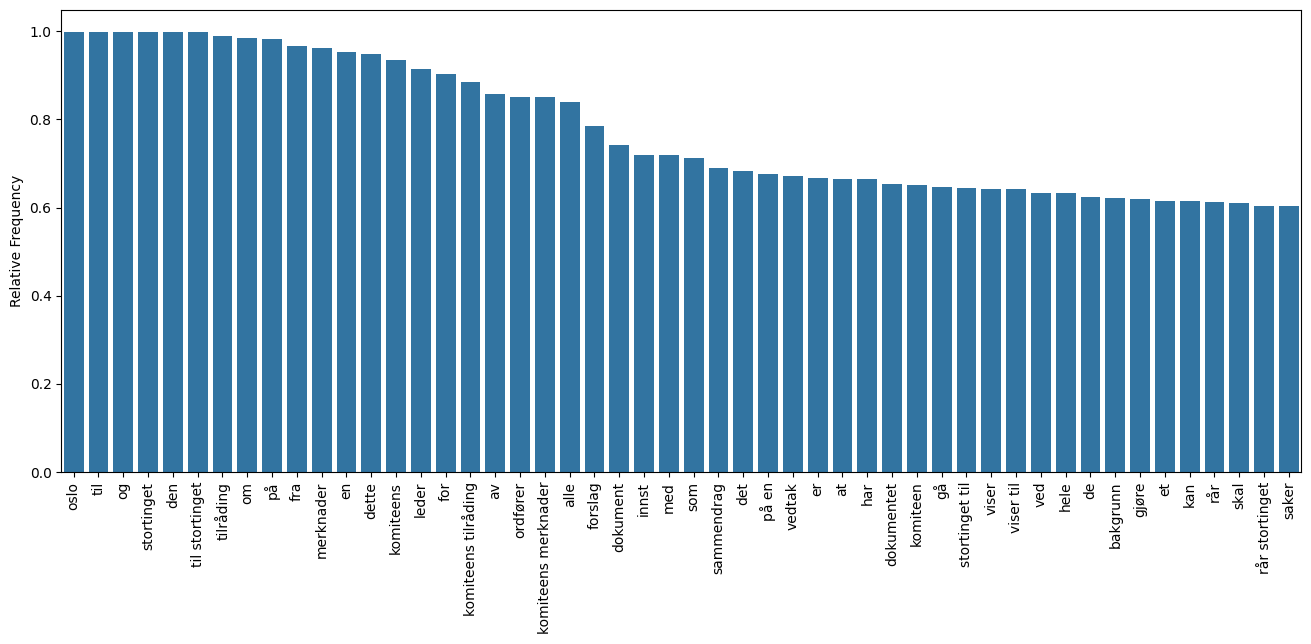

In [92]:
# Show the most common words
word_freq = train_T.sum(axis=0)
words = pd.DataFrame(data={'words':vect.get_feature_names_out(), 'frequency': word_freq / train_T.shape[0]})
aa = words.sort_values('frequency', ascending=False).iloc[:50]

fig, ax = plt.subplots(figsize=[16, 6])
sns.barplot(x='words', y='frequency', data=aa, ax=ax)
ax.set(ylabel='Relative Frequency', xlabel='')
ax.tick_params(axis='x', labelrotation=90)

# Results using stop-words

In [ ]:
import ast
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from PySparseCoalescedTsetlinMachineCUDA.tm import MultiOutputTsetlinMachine

In [ ]:
filepath = '../../data/stortinget_dataset_clean.csv'
df = pd.read_csv(filepath)
df['emneord'] = df['emneord'].apply(ast.literal_eval)
df.head()

In [275]:
all_emneord = np.sort(np.unique(df['emneord'].sum()))
emnedict = {str(k): v for v, k in zip(range(len(all_emneord)), all_emneord)}

print(f"Number of unique labels: {len(emnedict)}")

# Use only the 10 most common labels
tags, counts = np.unique(df['emneord'].sum(), return_counts=True)
common_tags_ind = np.argsort(-counts)[:10]

print("Most common labels\n", "-"*20)
emnedict_reduced = {}
for i, tag in enumerate(common_tags_ind):
    print(f"{tags[tag]} -- {counts[tag]}")
    emnedict_reduced[str(tags[tag])] = i

print(f"\nReduced emnedict: {emnedict_reduced}")

Number of unique labels: 163
Most common labels
 --------------------
Eu/eøs -- 1090
Trygder -- 810
Helsevesen -- 791
Innvandrere -- 650
Forurensning -- 629
Internasjonalt samarbeid -- 535
Politi og påtalemyndighet -- 513
Departementer -- 502
Forskning -- 496
Kommunikasjonsteknologi -- 491

Reduced emnedict: {'Eu/eøs': 0, 'Trygder': 1, 'Helsevesen': 2, 'Innvandrere': 3, 'Forurensning': 4, 'Internasjonalt samarbeid': 5, 'Politi og påtalemyndighet': 6, 'Departementer': 7, 'Forskning': 8, 'Kommunikasjonsteknologi': 9}


In [281]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split as tts


train, test = tts(df, test_size=0.2, random_state=1)
test_samples = test.index
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

corpus = list(train.loc[:, 'sammendrag'].values)
vect = CountVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    binary=True,
    stop_words=['og', 'til', 'av', 'for', 'om', 'fra', 'dette',
                'at', 'på', 'det', 'med', 'som', 'en', 'er', 'den',
                'har', 'frå', 'de', 'skal', 'nr', 'også', 'kan', 'et', 'ei', 'merknader']
)

tic = time()
vect.fit(corpus)
toc = time()
print(f"Vectorizer trained in {toc - tic:.3f} seconds")

tic = time()
X_train = vect.transform(corpus).toarray()
toc = time()
print(f"Corpus transformed in {toc-tic:.3f} seconds")

tic = time()
X_test = vect.transform(list(test.loc[:, 'sammendrag'].values)).toarray()
toc = time()
print(f"Test data transformed in {toc-tic:.3f} seconds")

Vectorizer trained in 68.033 seconds
Corpus transformed in 31.822 seconds
Test data transformed in 8.746 seconds


In [282]:
# Get the encoded labels

emneset = set(emnedict_reduced.keys())
def get_target_vect(df, emneset):
    Y = np.zeros([df.shape[0], len(emneset)], dtype=int)
    for i in range(df.shape[0]):
        labels = set(df.loc[i, 'emneord']).intersection(emneset)
        for l in labels:
            Y[i, emnedict_reduced[l]] = 1
    return Y


Y_train = get_target_vect(train.iloc[:], emneset)
Y_test = get_target_vect(test.iloc[:], emneset)

# Remove samples without any labels
X_train = X_train[np.sum(Y_train, axis=1) > 0]
Y_train = Y_train[np.sum(Y_train, axis=1) > 0]
X_test = X_test[np.sum(Y_test, axis=1) > 0]
Y_test = Y_test[np.sum(Y_test, axis=1) > 0]

print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of test samples:     {X_test.shape[0]}")

Number of training samples: 3275
Number of test samples:     810


In [283]:
tm = MultiOutputTsetlinMachine(
    number_of_clauses=20000,
    T=41000,
    s=1.0,
    q=2,
    max_included_literals=16,
)

for i in range(3):
    tm.fit(X_train, Y_train, epochs=1)
    Y_pred, cs = tm.predict(X_test)
    print(f"-- {i} --", end='\n')
    print(classification_report(Y_test, Y_pred, target_names=emnedict_reduced.keys(), zero_division=np.nan))

# Get the clauses
L = tm.get_literals()

-- 0 --
                           precision    recall  f1-score   support

                   Eu/eøs       0.78      0.90      0.83       213
                  Trygder       0.73      0.97      0.83       160
               Helsevesen       0.83      0.89      0.86       155
              Innvandrere       0.74      0.88      0.80       115
             Forurensning       0.83      0.90      0.86       131
 Internasjonalt samarbeid       0.51      0.87      0.64       107
Politi og påtalemyndighet       0.82      0.92      0.87        91
            Departementer       0.49      0.92      0.64        96
                Forskning       0.53      0.65      0.58       108
  Kommunikasjonsteknologi       0.65      0.71      0.68        96

                micro avg       0.69      0.87      0.77      1272
                macro avg       0.69      0.86      0.76      1272
             weighted avg       0.71      0.87      0.77      1272
              samples avg       0.79      0.90      

-- 1 --
                           precision    recall  f1-score   support

                   Eu/eøs       0.79      0.89      0.83       213
                  Trygder       0.72      0.97      0.83       160
               Helsevesen       0.84      0.88      0.86       155
              Innvandrere       0.73      0.88      0.80       115
             Forurensning       0.84      0.90      0.87       131
 Internasjonalt samarbeid       0.51      0.87      0.64       107
Politi og påtalemyndighet       0.83      0.92      0.88        91
            Departementer       0.48      0.92      0.63        96
                Forskning       0.53      0.66      0.59       108
  Kommunikasjonsteknologi       0.66      0.73      0.69        96

                micro avg       0.69      0.87      0.77      1272
                macro avg       0.69      0.86      0.76      1272
             weighted avg       0.71      0.87      0.78      1272
              samples avg       0.79      0.90      

-- 2 --
                           precision    recall  f1-score   support

                   Eu/eøs       0.80      0.88      0.84       213
                  Trygder       0.75      0.96      0.84       160
               Helsevesen       0.82      0.88      0.85       155
              Innvandrere       0.74      0.88      0.80       115
             Forurensning       0.84      0.90      0.87       131
 Internasjonalt samarbeid       0.51      0.87      0.64       107
Politi og påtalemyndighet       0.85      0.92      0.88        91
            Departementer       0.49      0.92      0.64        96
                Forskning       0.53      0.66      0.59       108
  Kommunikasjonsteknologi       0.66      0.70      0.68        96

                micro avg       0.69      0.86      0.77      1272
                macro avg       0.70      0.86      0.76      1272
             weighted avg       0.72      0.86      0.78      1272
              samples avg       0.79      0.89      

True features: 
 ['Politi og påtalemyndighet']


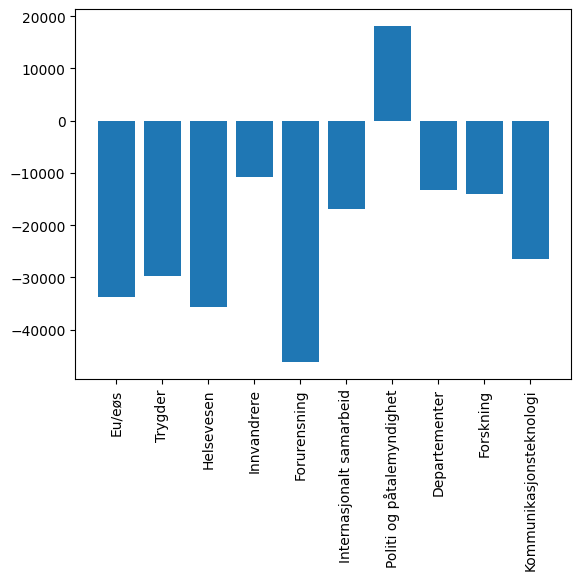

In [284]:
sample_id = 12

Y_pred, cs = tm.predict(X_train)
reverse_dict = {v:k for k, v in emnedict_reduced.items()}
print("True features: \n", [[reverse_dict[int(label)] for label in x] for x in np.nonzero(Y_train[sample_id])][0])

fig, ax = plt.subplots()
ax.bar(emnedict_reduced.keys(), cs[sample_id])
ax.tick_params(axis='x', labelrotation=90)

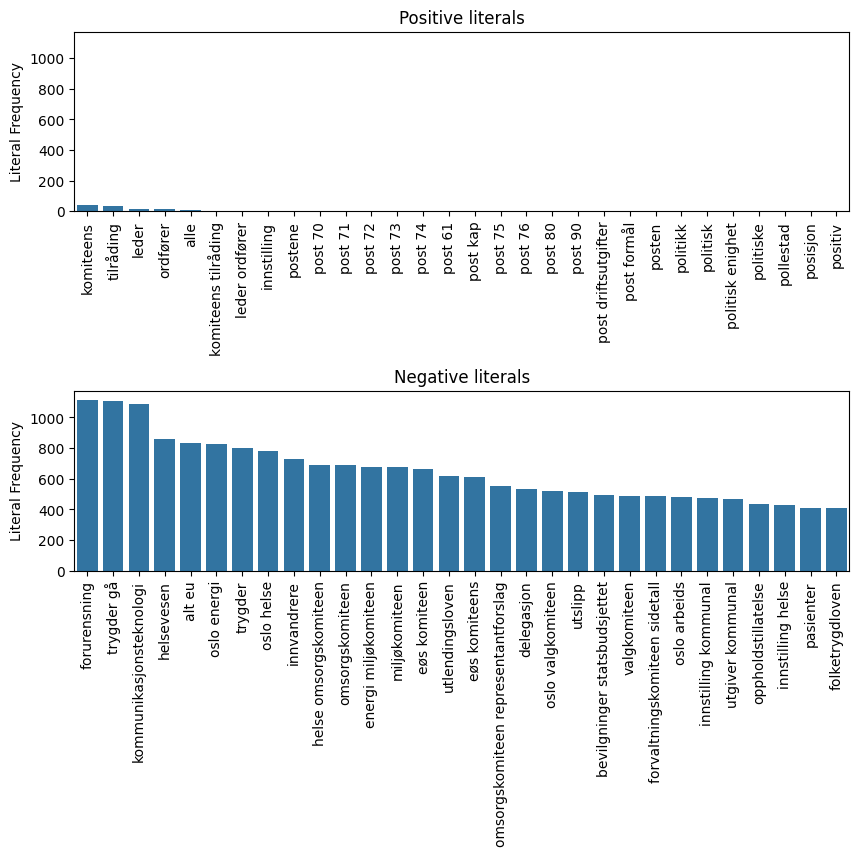

In [285]:
#sample_id = 12

# Get active clauses
T_train = tm.transform(X_train[sample_id].reshape(1, -1))

# Get the clauses. 
# Shape: [number_of_clauses X number of features
L_active = L[T_train.toarray()[0] == 1, :]
Lpos = L_active[:, :L.shape[1]//2].astype(int)
Lneg = L_active[:, L.shape[1]//2:].astype(int)

# Show most common word in active clauses
n_words = 30

df_pos = pd.DataFrame(data={'words':vect.get_feature_names_out(), 'literal freq':Lpos.sum(axis=0)})
df_pos = df_pos.sort_values('literal freq', ascending=False).reset_index(drop=True)[:n_words]

# Show the most common words
df_neg = pd.DataFrame(data={'words':vect.get_feature_names_out(), 'literal freq':Lneg.sum(axis=0)})
df_neg = df_neg.sort_values('literal freq', ascending=False).reset_index(drop=True)[:n_words]

fig, axs = plt.subplots(2, 1, figsize=[10, 7], sharey=True, gridspec_kw={'hspace':1})

sns.barplot(x='words', y='literal freq', data=df_pos, ax=axs[0])
axs[0].set(ylabel='Literal Frequency', xlabel='')
axs[0].tick_params(axis='x', labelrotation=90)
axs[0].set_title('Positive literals')


sns.barplot(x='words', y='literal freq', data=df_neg, ax=axs[1])
axs[1].set(ylabel='Literal Frequency', xlabel='')
axs[1].tick_params(axis='x', labelrotation=90)
axs[1].set_title('Negative literals')

plt.show()

Text(0.5, 0.98, 'Weight distributions')

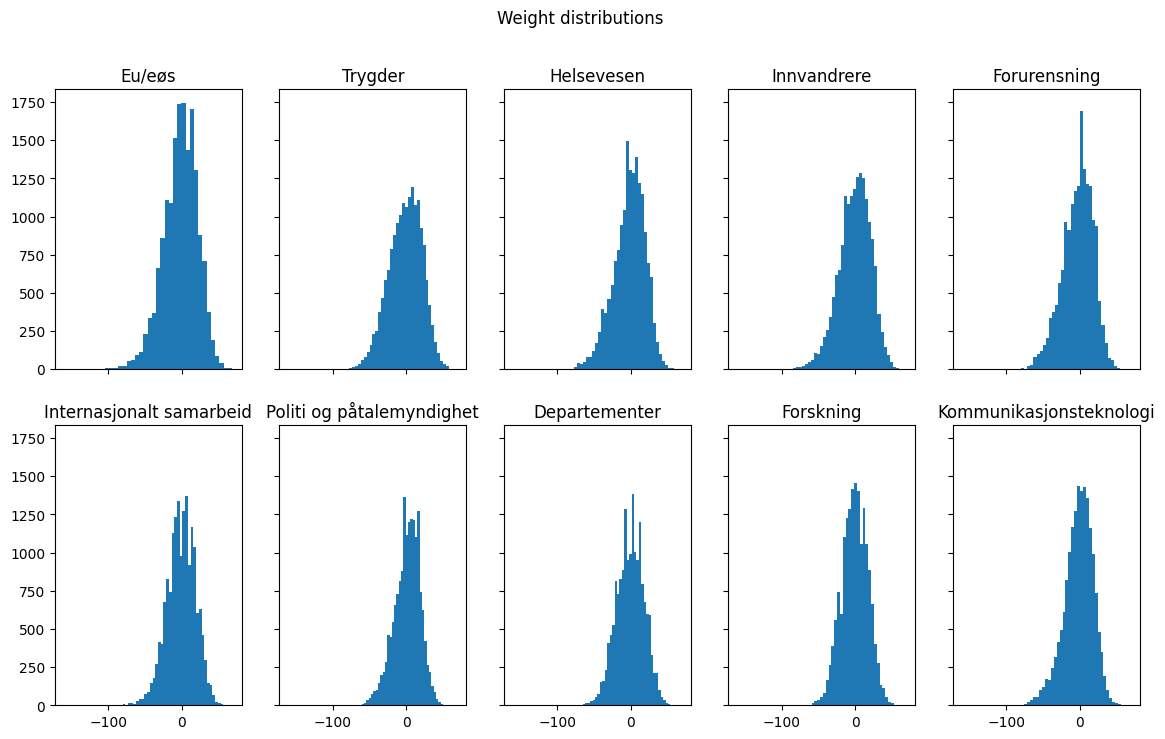

In [314]:
W = tm.get_weights()

fig, axs = plt.subplots(2, 5, figsize=[14, 8], sharey=True, sharex=True)
axs = axs.flatten()
for i in range(10):
    W_act = W[i, T_train.toarray()[0] == 1]
    axs[i].hist(W_act,bins=40);
    axs[i].set_title(reverse_dict[i])
plt.suptitle("Weight distributions")

# PLS visualization

In [350]:
from sklearn.cross_decomposition import PLSCanonical

pls = PLSCanonical(n_components=4)
pls.fit(X_train, Y_train)

TT = pls.transform(X_train)

## PLS scores

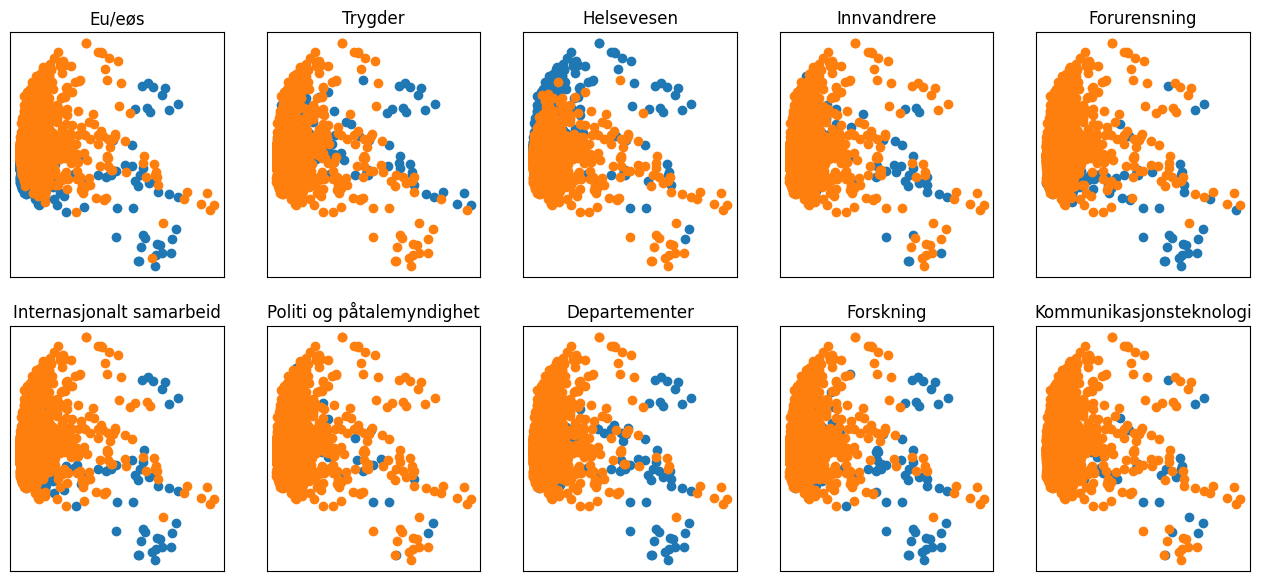

In [349]:
fig, axs = plt.subplots(2, 5, figsize=[16, 7])
axs = axs.flatten()
for i in range(10):
    axs[i].scatter(TT[Y_train[:, i] == 1,0], TT[Y_train[:, i] == 1,1])
    axs[i].scatter(TT[Y_train[:, i] != 1,0], TT[Y_train[:, i] != 1,1])
    axs[i].set_title(reverse_dict[i])
    axs[i].set(xticks=[], yticks=[])

## PLS loadings

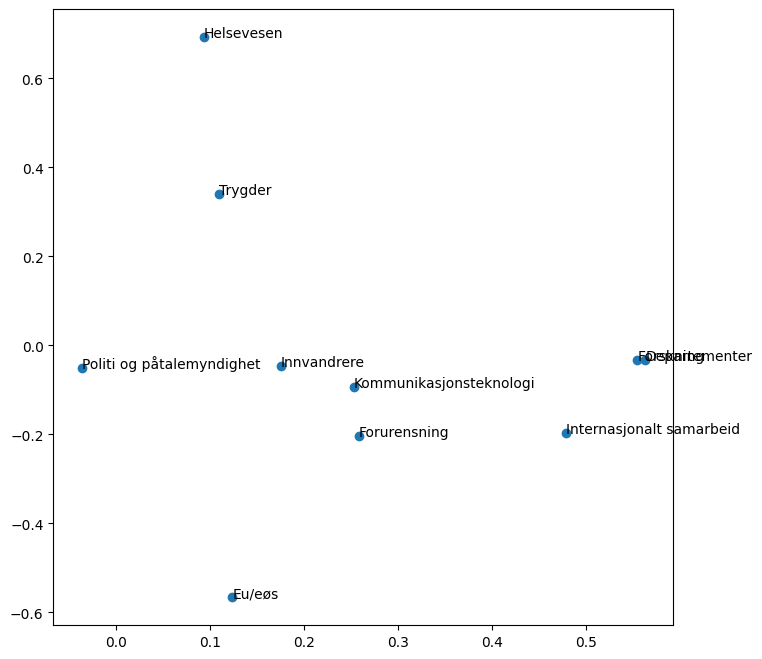

In [337]:
plt.figure(figsize=[8, 8])

plt.scatter(pls.y_loadings_[:, 0], pls.y_loadings_[:, 1])
for i, ss in enumerate(list(emnedict_reduced.keys())):
    plt.text(pls.y_loadings_[i, 0], pls.y_loadings_[i, 1], str(ss))